# Introduction

Human Immunodeficiency Virus (HIV) remains a major global health challenge, making the discovery of new anti-HIV compounds an important area of pharmaceutical research. Traditional laboratory screening of thousands of chemical compounds is time-consuming, expensive, and resource-intensive. Machine learning provides a faster and more cost-effective approach by predicting whether a molecule is likely to exhibit anti-HIV activity based on its chemical structure.

In this project, molecular structures represented as SMILES strings are converted into numerical representations (such as molecular embeddings or graph-based features) and used to train machine learning models. The trained model classifies each molecule as HIV-active or HIV-inactive, helping researchers prioritize promising compounds for further experimental validation. This approach accelerates the drug discovery process while reducing the cost and effort required for laboratory testing

**RDKit** is a popular open-source cheminformatics library in Python used to process and analyze chemical molecules. It can read molecular structures (such as SMILES), convert them into molecular graphs, generate molecular fingerprints and descriptors, visualize molecules, and prepare molecular features for machine learning and deep learning models. RDKit is widely used in drug discovery, molecular property prediction, and computational chemistry.

In [2]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 51.3 MB/s eta 0:00:00


**Pandas** (pd) – Used to load, organize, and manipulate tabular dataset data.

**NumPy** (np) – Used for numerical computations and array operations.

**RDKit** (Chem) – Used to read and process molecular structures from SMILES.

**RDKit** (AllChem) – Used to generate molecular fingerprints and other chemical features.

**train_test_split** – Splits the dataset into training and testing sets.

**RandomForestClassifier** – Builds a Random Forest model for molecule classification.

**accuracy_score** – Calculates the overall prediction accuracy of the model.

**classification_report** – Displays precision, recall, F1-score, and support for each class.

**confusion_matrix** – Summarizes the model's correct and incorrect predictions.

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Import HIV dataset

In [4]:
df = pd.read_csv("/content/HIV.csv")
df.head()


,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0


**morgan_fp**(smiles) is a function that converts a molecule represented as a SMILES string into a numerical fingerprint.

It uses RDKit to parse the SMILES and generate a 2048-bit Morgan fingerprint with a radius of 2, capturing the molecule's structural features.

The fingerprint is returned as a NumPy array, making it suitable as input for machine learning models.

In [5]:
def morgan_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol,radius=2,nBits=2048 )
    return np.array(fp)

* This code iterates through each molecule in the dataset, converts its SMILES string into a Morgan fingerprint, and ignores invalid molecules.
* The generated fingerprints are stored in X_list, while the corresponding HIV activity labels are stored in y_list.
* Finally, both lists are converted into NumPy arrays (X and y) for use in machine learning model training and evaluation.




In [8]:
X_list = []
y_list = []

for index, row in df.iterrows():
    smile = row["smiles"]
    fp = morgan_fp(smile)
    if fp is not None:
        X_list.append(fp)
        y_list.append(row["HIV_active"])

X = np.array(X_list)
y = np.array(y_list)

Streaming output truncated to the last 5000 lines.
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:17:53] DEPRECATION WARNING: please use MorganGenerator
[06:1

Divide the dataset in to train and test set

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

* RandomForestClassifier(n_estimators=300,
random_state=42) creates a Random Forest model with 300 decision trees and a fixed random seed for reproducible results.
* model.fit(X_train, y_train) trains the model using the training data, allowing it to learn the relationship between molecular fingerprints and HIV activity labels.
* After training, the model can predict whether new molecules are HIV-active or HIV-inactive.

In [12]:
model = RandomForestClassifier(n_estimators=300,random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

model.predict(X_test) uses the trained Random Forest model to predict the HIV activity of the molecules in the test dataset.
The predicted class labels (HIV-active or HIV-inactive) are stored in the variable y_pred.
These predictions are then compared with the true labels to evaluate the model's performance using metrics such as accuracy, confusion matrix, and classification report.

In [13]:
y_pred = model.predict(X_test)

In [14]:
print(classification_report( y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8120
           1       0.73      0.34      0.47       262

    accuracy                           0.98      8382
   macro avg       0.86      0.67      0.73      8382
weighted avg       0.97      0.98      0.97      8382



# Classification Report Interpretation
## Class 0 (HIV Inactive):
Precision = 0.98: 98% of the molecules predicted as inactive were actually inactive.
* Recall = 1.00: The model correctly identified almost all inactive molecules.
* F1-score = 0.99: Excellent overall performance for the inactive class.
## Class 1 (HIV Active):
* Precision = 0.73: 73% of the molecules predicted as active were truly active.
* Recall = 0.34: The model identified only 34% of the actual active molecules, missing many active compounds.
* F1-score = 0.47: Moderate performance for the active class due to the low recall.
* Overall Accuracy = 0.98 (98%): The model correctly classified 98% of all molecules. However, this high accuracy is mainly due to the large number of inactive molecules in the dataset.
* Macro Average: Precision (0.86), Recall (0.67), and F1-score (0.73) indicate the average performance across both classes, treating each class equally.
* Weighted Average: Precision (0.97), Recall (0.98), and F1-score (0.97) are weighted by the number of samples in each class, showing good overall performance but influenced by the majority inactive class.

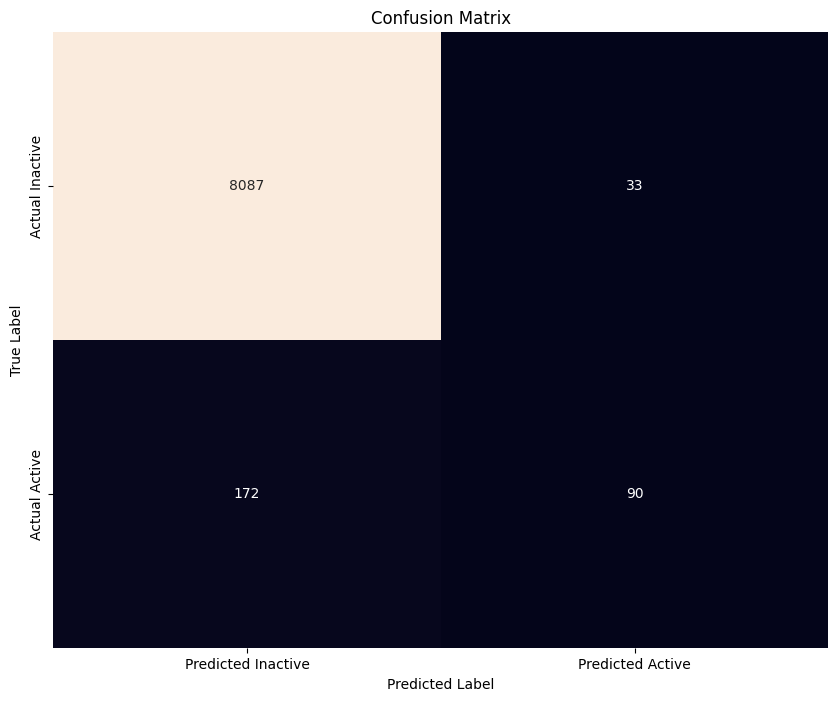

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=['Predicted Inactive', 'Predicted Active'],
            yticklabels=['Actual Inactive', 'Actual Active'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**The confusion matrix provides a detailed breakdown of your model's performance on the test set. Based on the plot and the values in the cm variable ([[8087, 33], [172, 90]]), here's what it tells us:**

#True Negatives (TN): 8087

These are the instances where the model correctly predicted that a molecule was inactive (Class 0), and it truly was inactive. This is the top-left cell.
#False Positives (FP): 33

These are the instances where the model incorrectly predicted that a molecule was active (Class 1), but it was actually inactive. This is the top-right cell, also known as a Type I error.
#False Negatives (FN): 172

These are the instances where the model incorrectly predicted that a molecule was inactive (Class 0), but it was actually active. This is the bottom-left cell, also known as a Type II error. In drug discovery, missing active compounds (false negatives) can be particularly problematic.
#True Positives (TP): 90

These are the instances where the model correctly predicted that a molecule was active (Class 1), and it truly was active. This is the bottom-right cell.
From these numbers, we can see that your model is very good at identifying inactive compounds (high True Negatives) but struggles more with correctly identifying all active compounds (relatively higher False Negatives).

#The End